In [46]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import os
for dirname, _, filenames in os.walk('inputs'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

inputs\comments.csv
inputs\follows.csv
inputs\likes.csv
inputs\photos.csv
inputs\photo_tags.csv
inputs\tags.csv
inputs\users.csv


In [47]:
import os
dest_path = 'inputs'

file_names = os.listdir(dest_path)
file_names

['comments.csv',
 'follows.csv',
 'likes.csv',
 'photos.csv',
 'photo_tags.csv',
 'tags.csv',
 'users.csv']

In [48]:
import pandas as pd

users = pd.read_csv('inputs/users.csv')
photos = pd.read_csv('inputs/photos.csv')
likes = pd.read_csv('inputs/likes.csv')
comments = pd.read_csv('inputs/comments.csv')
follows = pd.read_csv('inputs/follows.csv')

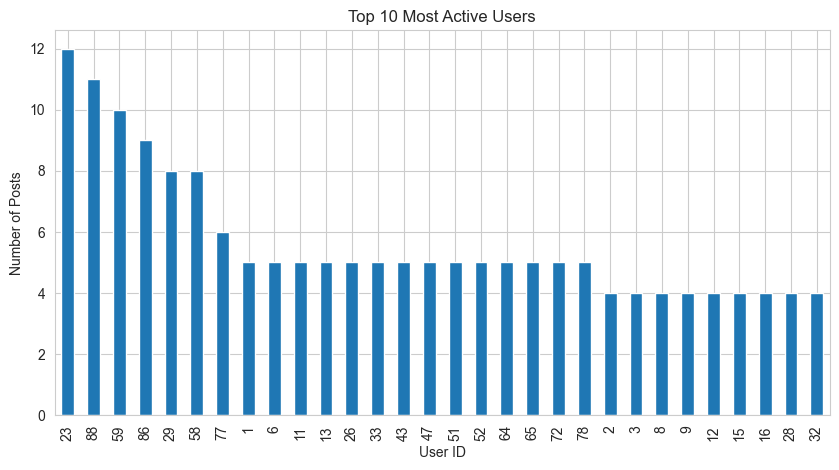

In [56]:
posts_per_user = photos['user_id'].value_counts()

top_users = posts_per_user.head(30)

plt.figure(figsize=(10,5))
top_users.plot(kind='bar')
plt.title("Top 10 Most Active Users")
plt.xlabel("User ID")
plt.ylabel("Number of Posts")
plt.show()

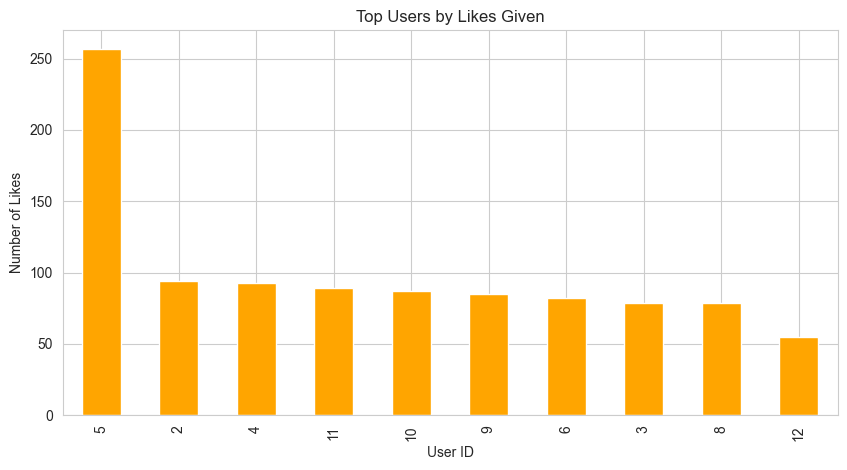

In [60]:
likes_per_user = likes['user_id'].value_counts().head(10)

plt.figure(figsize=(10,5))
likes_per_user.plot(kind='bar', color='orange')
plt.title("Top Users by Likes Given")
plt.xlabel("User ID")
plt.ylabel("Number of Likes")
plt.show()

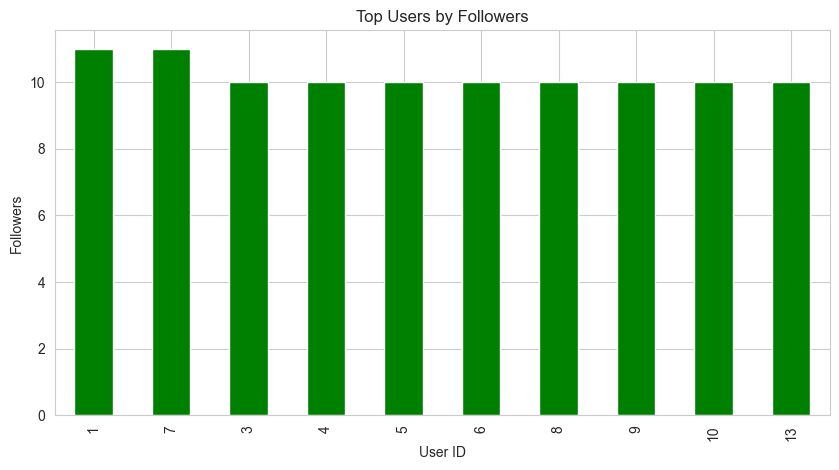

In [51]:
followers_count = follows['followee_id'].value_counts().head(10)

plt.figure(figsize=(10,5))
followers_count.plot(kind='bar', color='green')
plt.title("Top Users by Followers")
plt.xlabel("User ID")
plt.ylabel("Followers")
plt.show()

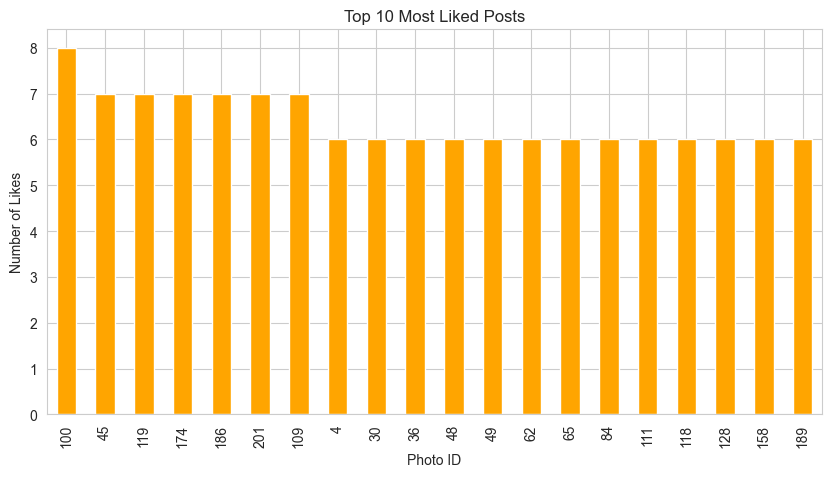

In [52]:

likes_per_post = likes['photo_id'].value_counts()

top_liked_posts = likes_per_post.head(20)

plt.figure(figsize=(10,5))
top_liked_posts.plot(kind='bar', color='orange')
plt.title("Top 10 Most Liked Posts")
plt.xlabel("Photo ID")
plt.ylabel("Number of Likes")
plt.show()

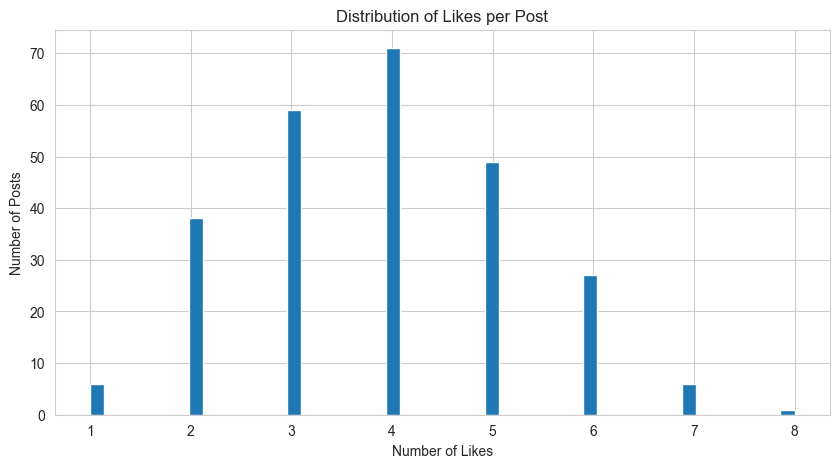

In [53]:
plt.figure(figsize=(10,5))
likes_per_post.hist(bins=50)
plt.title("Distribution of Likes per Post")
plt.xlabel("Number of Likes")
plt.ylabel("Number of Posts")
plt.show()

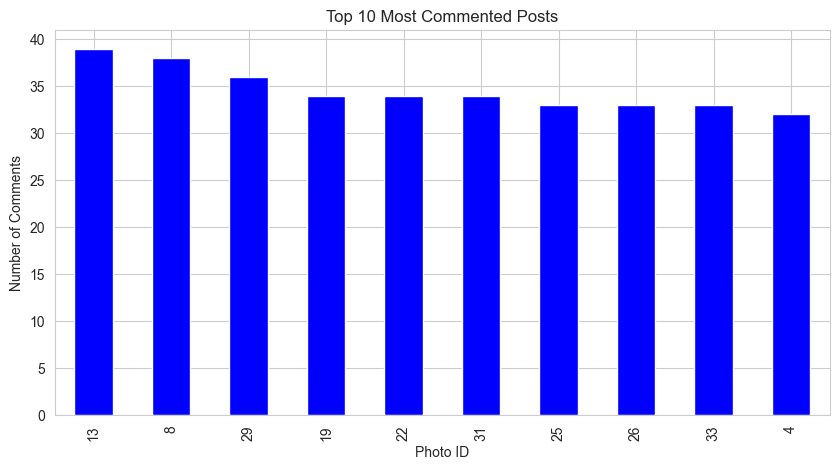

In [54]:
comments_per_post = comments['photo_id'].value_counts().head(10)

plt.figure(figsize=(10,5))
comments_per_post.plot(kind='bar', color='blue')
plt.title("Top 10 Most Commented Posts")
plt.xlabel("Photo ID")
plt.ylabel("Number of Comments")
plt.show()

In [62]:
followers_count = follows['followee_id'].value_counts().reset_index()
followers_count.columns = ['user_id', 'followers']
likes_user = photos.merge(likes, left_on='id', right_on='photo_id')
likes_per_user = likes_user.groupby('user_id_x').size().reset_index(name='likes')
likes_per_user.rename(columns={'user_id_x': 'user_id'}, inplace=True)
df = pd.merge(followers_count, likes_per_user, on='user_id', how='inner')

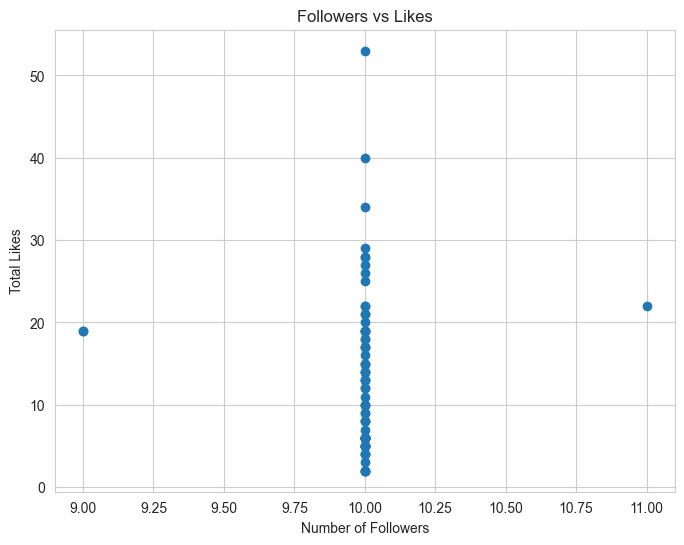

In [63]:
plt.figure(figsize=(8,6))
plt.scatter(df['followers'], df['likes'])
plt.title("Followers vs Likes")
plt.xlabel("Number of Followers")
plt.ylabel("Total Likes")
plt.show()

In [ ]:
df['influence_score'] = df['followers'] + df['likes']
top_influencers = df.sort_values(by='influence_score', ascending=False).head(10)

top_influencers

,user_id,followers,likes,influence_score
15,23,10,53,63
41,59,10,40,50
61,88,10,34,44
40,58,10,29,39
23,33,10,28,38
59,86,10,28,38
30,43,10,27,37
19,29,10,26,36
53,77,10,25,35
0,1,11,22,33


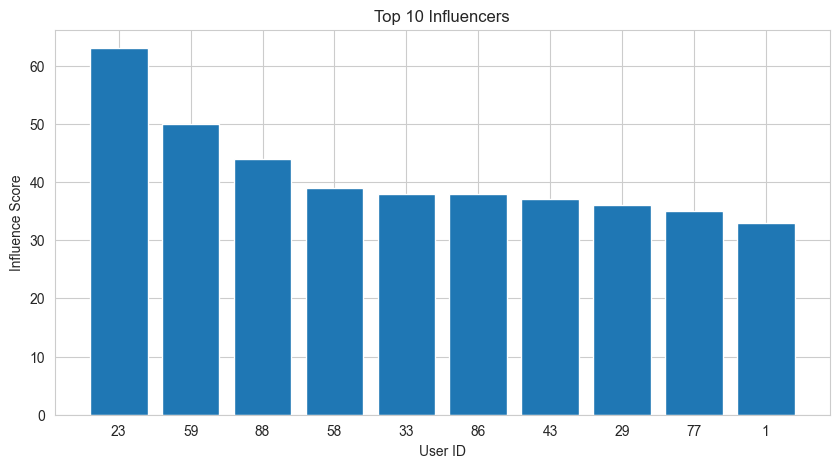

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(top_influencers['user_id'].astype(str), top_influencers['influence_score'])
plt.title("Top 10 Influencers")
plt.xlabel("User ID")
plt.ylabel("Influence Score")
plt.show()
